<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">🕸️ El Grafo Detrás del Agente</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 5 — Construir con LangGraph, nodo por nodo, lo que create_agent hace por dentro</p>
</div>

<code>create_agent</code> es conveniente, pero es una caja negra: recibe un modelo y unas herramientas, y devuelve un agente ya armado. Este notebook construye ese mismo agente ReAct <strong>a mano</strong>, con <strong>LangGraph</strong>: un grafo explícito de nodos y aristas. Entender esa estructura es lo que permite, más adelante, personalizar el flujo de un agente más allá de lo que <code>create_agent</code> permite (por ejemplo, aprobación humana antes de ciertas acciones).

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#conceptos-langgraph">Estado, nodos y aristas</a></li>
<li><a href="#construir-grafo">Construir el grafo del agente</a></li>
<li><a href="#visualizar-ejecutar">Visualizar y ejecutar el grafo</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="conceptos-langgraph"></a>

## <span style="color:#F97066;">Estado, nodos y aristas</span>

LangGraph modela un agente como un **grafo**: los datos que fluyen por él son el **estado** (en este caso, la lista de `messages` de la conversación), los **nodos** son funciones que reciben el estado y devuelven una actualización de ese estado, y las **aristas** conectan nodos entre sí — algunas fijas, y otras **condicionales** (deciden a qué nodo ir según el contenido del estado).

El ciclo ReAct completo se puede expresar con solo dos nodos:

- **`modelo`**: le pasa el historial de mensajes al LLM y obtiene su respuesta (que puede ser una respuesta final, o una petición de invocar una herramienta).
- **`herramientas`**: ejecuta la herramienta que el LLM pidió invocar, y agrega el resultado a la conversación.

Y una arista condicional que, después de `modelo`, decide: si el LLM pidió una herramienta, ir a `herramientas`; si no, terminar.

<a id="construir-grafo"></a>

## <span style="color:#F97066;">Construir el grafo del agente</span>

<span style="color:#F97066;">1.</span> El modelo y la herramienta (igual que en los notebooks anteriores).

In [1]:
import os
import logging
import math
from dotenv import load_dotenv

load_dotenv()
logging.getLogger("google_genai.models").setLevel(logging.ERROR)

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.tools import tool


@tool
def calcular_area_circulo(radio: float) -> str:
    """Calcula el área de un círculo dado su radio.

    Args:
        radio: El radio del círculo.
    """
    return f"{math.pi * radio ** 2:.2f}"


llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite", api_key=os.getenv("GOOGLE_API_KEY"))

# bind_tools() le informa al LLM qué herramientas existen, sin ejecutar nada todavía
llm_con_herramientas = llm.bind_tools([calcular_area_circulo])

print("Modelo con herramienta vinculada correctamente.")

Modelo con herramienta vinculada correctamente.


<span style="color:#F97066;">2.</span> El estado y el nodo del modelo

`MessagesState` es el esquema de estado predefinido de LangGraph para conversaciones: internamente, cada vez que un nodo devuelve nuevos `messages`, LangGraph los **agrega** a la lista existente (en vez de reemplazarla) — así el historial se acumula automáticamente turno a turno.

In [2]:
from langgraph.graph import StateGraph, MessagesState, START, END


def nodo_modelo(state: MessagesState):
    """Le pasa el historial de mensajes al LLM y devuelve su respuesta."""
    respuesta = llm_con_herramientas.invoke(state["messages"])
    return {"messages": [respuesta]}


print("Nodo del modelo definido correctamente.")

Nodo del modelo definido correctamente.


<span style="color:#F97066;">3.</span> El nodo de herramientas y el grafo completo

`ToolNode` es un nodo ya construido por LangGraph que, dado un mensaje con una petición de herramienta, la ejecuta y agrega el resultado como un `ToolMessage`. `tools_condition` es la arista condicional correspondiente: revisa el último mensaje y decide si hay que ir a `"tools"` o terminar (`END`).

In [3]:
from langgraph.prebuilt import ToolNode, tools_condition

grafo = StateGraph(MessagesState)

# 1. Registrar los nodos
grafo.add_node("modelo", nodo_modelo)
grafo.add_node("herramientas", ToolNode([calcular_area_circulo]))

# 2. Conectar las aristas
grafo.add_edge(START, "modelo")
grafo.add_conditional_edges("modelo", tools_condition, {"tools": "herramientas", END: END})
grafo.add_edge("herramientas", "modelo")  # tras ejecutar la herramienta, se vuelve al modelo

# 3. Compilar el grafo en una aplicación ejecutable
app = grafo.compile()

print("Grafo del agente compilado correctamente.")

Grafo del agente compilado correctamente.


<a id="visualizar-ejecutar"></a>

## <span style="color:#F97066;">Visualizar y ejecutar el grafo</span>

LangGraph puede dibujar el grafo compilado, lo que ayuda a verificar que su estructura es la esperada antes de ejecutarlo.

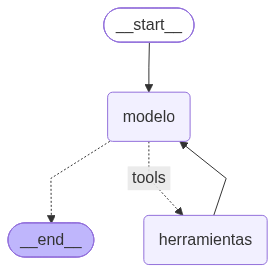

In [4]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

El diagrama muestra exactamente el ciclo descrito: de `modelo` se puede ir a `herramientas` (si el LLM pidió una) o terminar, y de `herramientas` siempre se vuelve a `modelo` para que el LLM procese el resultado. Ahora se ejecuta con una pregunta real.

In [5]:
resultado = app.invoke({"messages": [{"role": "user", "content": "Calcula el área de un círculo de radio 4 y explica el resultado."}]})

for mensaje in resultado["messages"]:
    tipo = mensaje.__class__.__name__
    contenido = mensaje.tool_calls if getattr(mensaje, "tool_calls", None) else mensaje.text
    print(f"[{tipo}] {contenido}")

[HumanMessage] Calcula el área de un círculo de radio 4 y explica el resultado.
[AIMessage] [{'name': 'calcular_area_circulo', 'args': {'radio': 4}, 'id': 'call_233343', 'type': 'tool_call'}]
[ToolMessage] 50.27
[AIMessage] El área de un círculo con un radio de 4 es aproximadamente **50.27**.

### Explicación:
La fórmula para calcular el área de un círculo es:
$$\text{Área} = \pi \times r^2$$

Donde:
* **$\pi$** (Pi) es una constante matemática aproximada a $3.1416$.
* **$r$** es el radio del círculo, que en este caso es $4$.

**Pasos del cálculo:**
1. Se eleva el radio al cuadrado: $4^2 = 4 \times 4 = 16$.
2. Se multiplica ese resultado por $\pi$: $16 \times \pi \approx 16 \times 3.14159 \approx 50.27$.


El recorrido es idéntico al de un agente construido con <code>create_agent</code>: mensaje del usuario → el modelo pide invocar <code>calcular_area_circulo</code> → se ejecuta la herramienta → el modelo recibe el resultado y responde. La diferencia es que aquí cada paso de ese recorrido está escrito explícitamente, lo que permite modificarlo: por ejemplo, agregar un tercer nodo que registre cada llamada a una herramienta en un archivo de auditoría, o una arista que se detenga antes de ejecutar ciertas herramientas para pedir aprobación humana.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
<code>create_agent</code> no es una alternativa distinta a esto: internamente construye un grafo prácticamente igual al de este notebook. Se usa <code>create_agent</code> cuando el patrón ReAct estándar alcanza, y se construye el grafo a mano cuando se necesita un flujo de control distinto al de ese patrón.
</div>

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>
Este notebook construyó el ciclo ReAct explícitamente con LangGraph:

- Un agente es un grafo: un **estado** compartido (la lista de mensajes), **nodos** que lo actualizan, y **aristas** (algunas condicionales) que conectan esos nodos.
- <code>MessagesState</code> agrega automáticamente los mensajes nuevos al historial existente.
- <code>ToolNode</code> y <code>tools_condition</code> son las piezas ya construidas por LangGraph para el nodo de herramientas y la decisión de invocarlas.
- <code>create_agent</code> construye, internamente, un grafo equivalente a este — se usa cuando el patrón ReAct estándar es suficiente.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>5-rag-como-herramienta.ipynb</code> — una herramienta que consulta información propia mediante recuperación aumentada por generación (RAG).</li>
</ul>
</div>